In [ ]:
 from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv(list(uploaded.keys())[0], encoding='latin1')
df.head()


Saving train.csv to train (1).csv


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
# Shape and structure
print("Shape (rows, columns):", df.shape)
print("\nColumn data types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

Shape (rows, columns): (9800, 18)

Column data types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

Missing values per column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [ ]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Postal Code'] = df['Postal Code'].fillna(0)

df['Order Month'] = df['Order Date'].dt.to_period('M')
df['Order Year'] = df['Order Date'].dt.year

print(df.dtypes)
print("\nRemaining missing values:", df.isnull().sum().sum())

ValueError: time data "15/04/2018" doesn't match format "%m/%d/%Y", at position 4. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')
df['Postal Code'] = df['Postal Code'].fillna(0)

df['Order Month'] = df['Order Date'].dt.to_period('M')
df['Order Year'] = df['Order Date'].dt.year

print(df.dtypes)
print("\nRemaining missing values:", df.isnull().sum().sum())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly_sales = df.groupby('Order Month')['Sales'].sum()

plt.figure(figsize=(14, 5))
monthly_sales.plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


KeyError: 'Order Month'

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')
df['Postal Code'] = df['Postal Code'].fillna(0)

df['Order Month'] = df['Order Date'].dt.to_period('M')
df['Order Year'] = df['Order Date'].dt.year

print(df.dtypes)
print("\nRemaining missing values:", df.isnull().sum().sum())

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Order Month           period[M]
Order Year                int32
dtype: object

Remaining missing values: 0


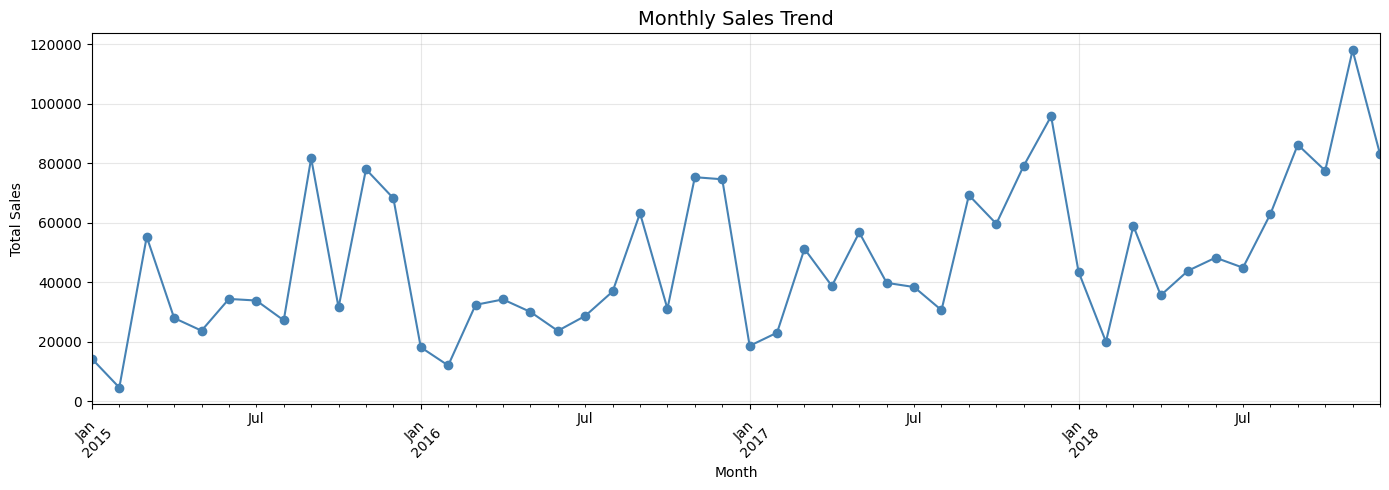

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly_sales = df.groupby('Order Month')['Sales'].sum()

plt.figure(figsize=(14, 5))
monthly_sales.plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** Monthly sales show a clear upward trend from 2015 to 2018, indicating overall business growth. There's also strong seasonality — sales consistently peak in November each year, likely due to holiday season demand, and drop sharply in the following January. This suggests the business should plan inventory and staffing around the Nov–Dec peak and consider promotional campaigns to offset the January slump.

/tmp/ipykernel_442/28520173.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.values, y=category_sales.index, palette='viridis')


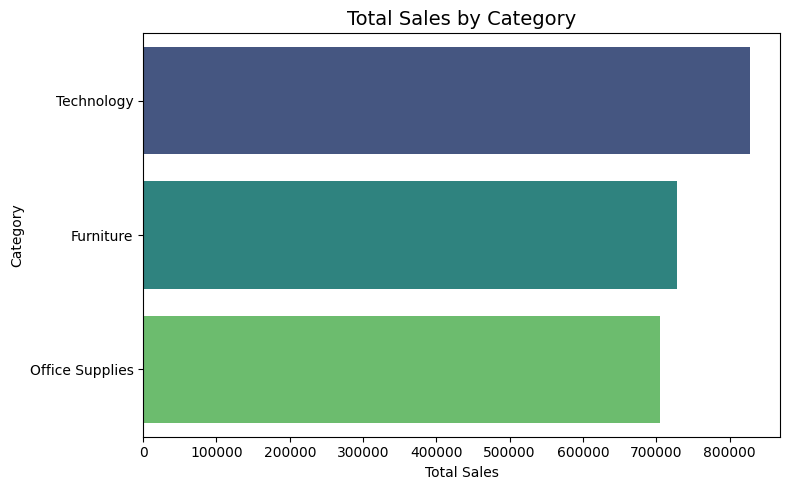

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.values, y=category_sales.index, palette='viridis')
plt.title('Total Sales by Category', fontsize=14)
plt.xlabel('Total Sales')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

**Observation:** Technology generates the highest total revenue (~₹830K), followed closely by Furniture (~₹730K) and Office Supplies (~₹710K). The relatively narrow gap between all three categories suggests the business isn't over-reliant on a single category, which is healthy — but it also means there's room to push Technology further given it already leads, or investigate why Office Supplies underperforms despite likely higher order volume (office supplies are usually low-cost, high-frequency items).

/tmp/ipykernel_442/3627961836.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='mako')


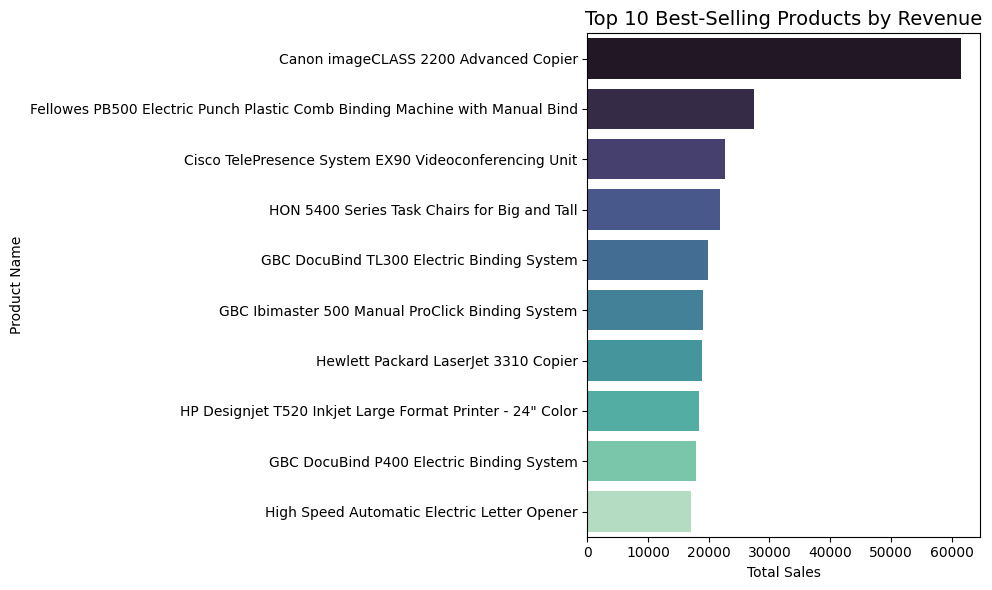

In [ ]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='mako')
plt.title('Top 10 Best-Selling Products by Revenue', fontsize=14)
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

**Observation:** The Canon imageCLASS 2200 Advanced Copier is by far the top revenue-generating product (~₹61K), more than double the second-highest product. Office equipment (copiers, binding machines, printers) dominates this top-10 list — reinforcing that Technology's category lead is likely driven by a small number of high-ticket items rather than broad volume across many products.

/tmp/ipykernel_442/3542998552.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='pastel')


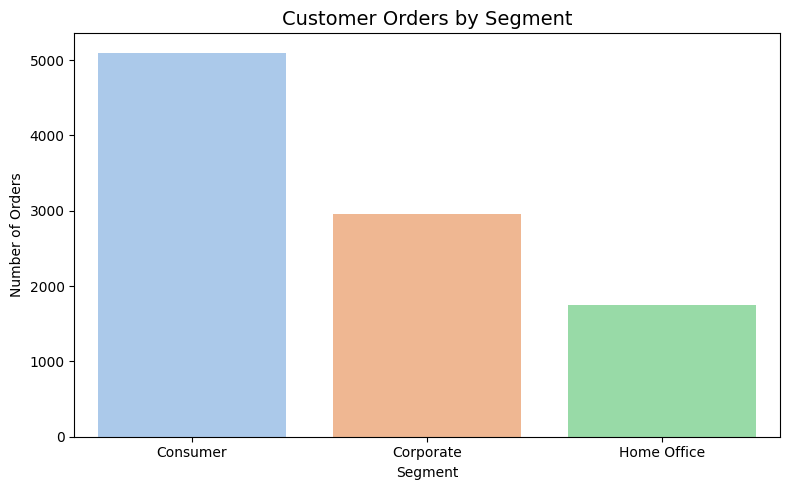

In [ ]:
plt.figure(figsize=(8, 5))
segment_counts = df['Segment'].value_counts()
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='pastel')
plt.title('Customer Orders by Segment', fontsize=14)
plt.xlabel('Segment')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

**Observation:** The Consumer segment drives the majority of orders (~5,100), nearly double the Corporate segment (~2,950) and almost triple Home Office (~1,750). This suggests the business's core customer base is individual buyers rather than businesses — worth considering for marketing spend allocation.

**Note:** This dataset does not include age or gender fields. Segment and Region were used as the closest available customer-demographic proxies for this analysis.

/tmp/ipykernel_442/1495399171.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette='coolwarm')


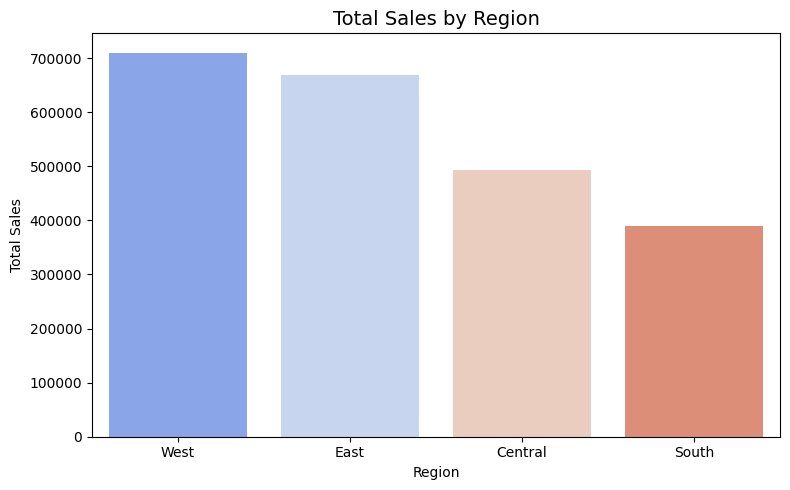

In [ ]:
plt.figure(figsize=(8, 5))
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values, palette='coolwarm')
plt.title('Total Sales by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

**Observation:** West (~₹710K) and East (~₹670K) generate significantly more revenue than Central (~₹495K) and South (~₹390K) — nearly double South's total. This regional imbalance suggests an opportunity: either West/East markets are more mature and should be defended, or Central/South represent untapped growth potential worth targeted investment.

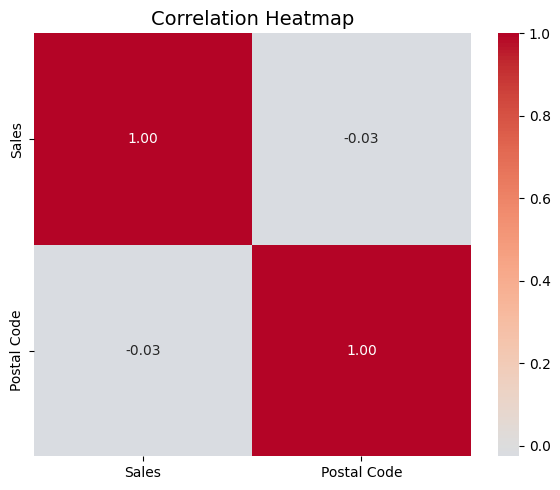

In [ ]:
numeric_cols = df[['Sales', 'Postal Code']]
correlation = numeric_cols.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

**Observation:** This dataset contains limited purely numeric columns, so the correlation heatmap shows only Sales and Postal Code. As expected, there's virtually no correlation (-0.03) between them, since Postal Code is a location identifier, not a meaningful numeric variable. This is a limitation of the dataset itself rather than the analysis — most of this dataset's value lies in its categorical fields (Category, Region, Segment), which is why the earlier bar charts carry more analytical weight than this heatmap.

/tmp/ipykernel_442/940159275.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcat_sales.values, y=subcat_sales.index, palette='crest')


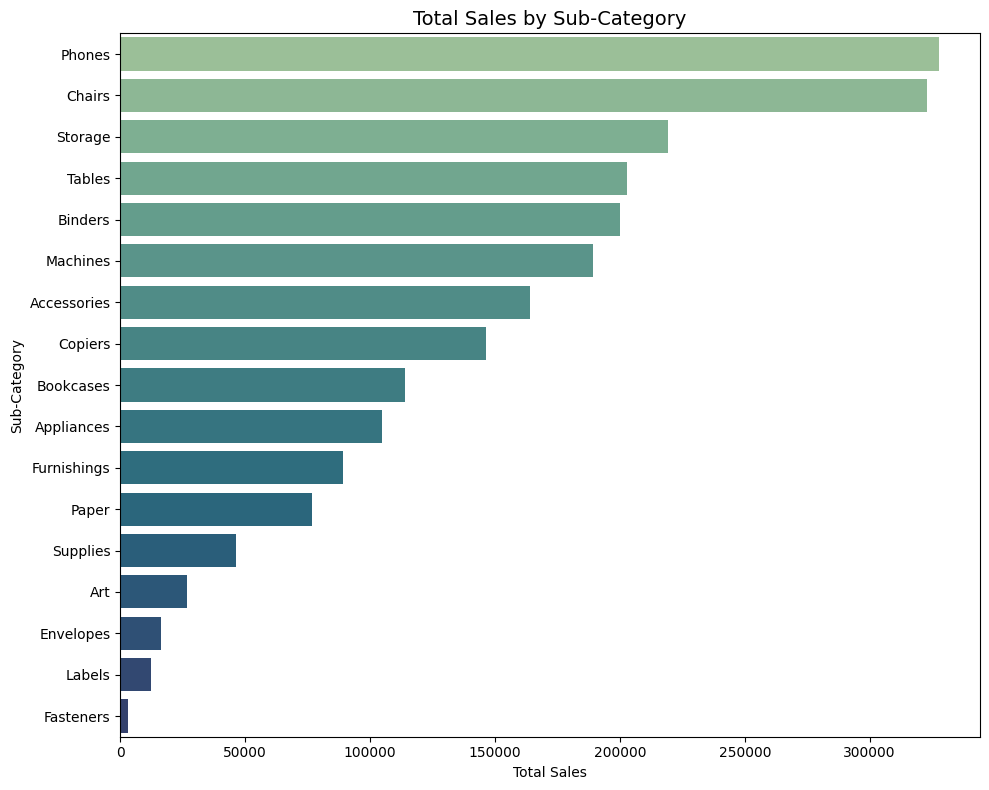

In [ ]:
plt.figure(figsize=(10, 8))
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=subcat_sales.values, y=subcat_sales.index, palette='crest')
plt.title('Total Sales by Sub-Category', fontsize=14)
plt.xlabel('Total Sales')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

**Observation:** Phones (~₹330K) and Chairs (~₹325K) are the top-performing sub-categories overall — interesting, because the single best-selling *product* was a Canon copier, yet Copiers as a sub-category ranks only 8th (~₹150K). This shows that Copiers' strength comes from one standout product, while Phones and Chairs generate revenue more broadly across multiple products. This is a more reliable growth signal than the single-product chart alone — the business should invest in the Phones and Chairs sub-categories as a whole, not just chase individual best-sellers.

## Conclusion & Business Recommendations

Based on this analysis, here are three actionable recommendations:

1. **Plan inventory and marketing around seasonality.** Sales consistently peak in November and dip in January each year. The business should build up stock and staffing ahead of the holiday season, and consider January promotions to soften the post-holiday slump.

2. **Invest in Phones and Chairs sub-categories.** These generate the most revenue overall, spread across multiple products — a more sustainable growth lever than relying on one standout product like the Canon copier.

3. **Target Central and South regions for growth.** West and East already lead in sales; Central and South show meaningfully lower revenue, representing untapped market potential for expansion or region-specific promotions.

In [ ]:
## Conclusion & Business Recommendations

Based on this analysis, here are three actionable recommendations:

1. **Plan inventory and marketing around seasonality.** Sales consistently peak in November and dip in January each year. The business should build up stock and staffing ahead of the holiday season, and consider January promotions to soften the post-holiday slump.

2. **Invest in Phones and Chairs sub-categories.** These generate the most revenue overall, spread across multiple products — a more sustainable growth lever than relying on one standout product like the Canon copier.

3. **Target Central and South regions for growth.** West and East already lead in sales; Central and South show meaningfully lower revenue, representing untapped market potential for expansion or region-specific promotions.